# GWTC-5.0 Catalog Tutorial: Population Overview and Single-Event Inference

## Overview

In this tutorial we work with two complementary datasets from the LIGO–Virgo–KAGRA
Gravitational-Wave Transient Catalog 5.0 (**GWTC-5.0**):

1. **The PESummary Table** (`IGWN-GWTC5p0-PESummaryTable.hdf5`): a compact table of
   posterior median values and 90% credible intervals for all ~104 events, each analysed
   with multiple waveform approximants.

2. **GW250114 Posterior Samples** (`GW250114_PEsummary.hdf5`): the full posterior
   distributions from the Bayesian parameter-estimation (PE) analysis of GW250114_082203,
   giving access to the complete multi-dimensional probability distribution over source
   parameters.

### What we will do

| Part | Content |
|------|---------|
| **Part 1 — Catalog overview** | Load and explore the summary table; select a consistent waveform model; visualise population trends with error bars; examine the SNR–precision relationship |
| **Part 2 — Single-event inference** | Load full posterior samples for GW250114; plot 1-D marginal posteriors; make corner plots showing parameter correlations; compare prior and posterior; compare across waveform models |

> **Prerequisite packages**: `gwpy`, `pesummary`, `numpy`, `matplotlib`, `corner`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import corner

from gwpy.table import EventTable
from pesummary.io import read

# ── Plot defaults ──────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})
print("All packages loaded successfully.")


All packages loaded successfully.


---
## Part 1: GWTC-5.0 Catalog — Population Overview

### Section 1 · Loading the Summary Table

The PESummary Table is an HDF5 file produced by the GWTC-5.0 analysis pipeline.
Each **row** corresponds to one parameter-estimation run: because several waveform
approximants are analysed for each event, the table has **more rows than unique events**.

Each **column** reports a marginalised 1-D parameter summary stored as three numbers:

| Column pattern | Meaning |
|----------------|---------|
| `X_median` | Posterior median (50th percentile) |
| `X_lower` | **Offset** below the median to the 5th percentile |
| `X_upper` | **Offset** above the median to the 95th percentile |

So the 90% credible interval for parameter $X$ is:
$$[X_\mathrm{median} - X_\mathrm{lower},\quad X_\mathrm{median} + X_\mathrm{upper}]$$

Available physics quantities include source-frame masses, effective spin $\chi_\mathrm{eff}$,
luminosity distance, redshift, and network matched-filter SNR.


In [2]:
summary_path = "./IGWN-GWTC5p0-59d160a18_25-PESummaryTable.hdf5"
summary_table = EventTable.read(summary_path)

unique_events = sorted(set(str(name) for name in summary_table['gw_name']))
print(f"File:           {summary_path}")
print(f"Total rows:     {len(summary_table)}  (multiple models per event)")
print(f"Unique events:  {len(unique_events)}")
print(f"Columns:        {len(summary_table.colnames)}")
print()
print("First 5 event names:", unique_events[:5])
print("Last  5 event names:", unique_events[-5:])


File:           ./IGWN-GWTC5p0-59d160a18_25-PESummaryTable.hdf5
Total rows:     377  (multiple models per event)
Unique events:  104
Columns:        45

First 5 event names: ['GW240413_022019', 'GW240414_054515', 'GW240420_175625', 'GW240426_031451', 'GW240428_225440']
Last  5 event names: ['GW250118_023225', 'GW250118_055802', 'GW250118_170523', 'GW250119_025138', 'GW250119_190238']


---
### Section 2 · Exploring the Table Structure

Let's inspect what waveform models are available and what kinds of parameters are stored.


In [3]:
# ── Available waveform approximants ───────────────────────────────────────────
model_counts = Counter(str(k) for k in summary_table['result_samples_key'])

print("Waveform approximants and the number of events analysed with each:")
print("─" * 68)
for model, count in sorted(model_counts.items(), key=lambda x: -x[1]):
    bar = "█" * (count // 3)
    print(f"  {model:<44s}  {count:>3d}  {bar}")
print("─" * 68)
print(f"  Total rows: {len(summary_table)}")


Waveform approximants and the number of events analysed with each:
────────────────────────────────────────────────────────────────────
  C00:IMRPhenomXPHM-SpinTaylor                  103  ██████████████████████████████████
  C00:IMRPhenomXPNR                             103  ██████████████████████████████████
  C00:SEOBNRv5PHM                               103  ██████████████████████████████████
  C00:NRSur7dq4                                  60  ████████████████████
  C00:Mixed                                       4  █
  C01:IMRPhenomXPHM-SpinTaylor                    1  
  C01:IMRPhenomXPNR                               1  
  C01:Mixed                                       1  
  C01:SEOBNRv5PHM                                 1  
────────────────────────────────────────────────────────────────────
  Total rows: 377


In [ ]:
# ── Column structure grouped by physics content ───────────────────────────────
colnames  = summary_table.colnames
mass_cols = [c for c in colnames if 'mass' in c and 'mask' not in c]
spin_cols = [c for c in colnames if ('chi' in c or 'spin' in c) and 'mask' not in c]
dist_cols = [c for c in colnames if 'distance' in c or 'redshift' in c]
snr_cols  = [c for c in colnames if 'snr' in c and 'mask' not in c]
id_cols   = ['result_label', 'gw_name', 'result_samples_key', 'superevent_id']

print("Identity columns:")
for c in id_cols:
    print(f"    {c}")

print("\nMass parameters  (each stored as: median / lower_offset / upper_offset):")
for c in mass_cols:
    print(f"    {c}")

print("\nSpin parameters:")
for c in spin_cols:
    print(f"    {c}")

print("\nDistance / redshift:")
for c in dist_cols:
    print(f"    {c}")

print("\nNetwork matched-filter SNR:")
for c in snr_cols:
    print(f"    {c}")


---
### Section 3 · Selecting One Consistent Waveform Model

Different waveform approximants make different modelling assumptions. Mixing them across
events would introduce systematic biases when comparing parameters. We therefore choose
**one model** as a reference for all population plots.

| Approximant | Description |
|-------------|-------------|
| **`C00:IMRPhenomXPHM-SpinTaylor`** | Precessing, higher-mode phenomenological model with spin-Taylor phase. Covers 103/104 events — our choice. |
| `C00:IMRPhenomXPNR` | Next-generation precessing model with NR-tuned precession phase |
| `C00:SEOBNRv5PHM` | Spinning effective-one-body model with precession and higher modes |
| `C00:NRSur7dq4` | Direct NR surrogate (restricted to moderate mass ratios and spins) |

Let's also look at a specific row — **GW250114_082203** — to understand the format
before building population plots.


In [4]:
MODEL_KEY = "C00:IMRPhenomXPHM-SpinTaylor"
imr_table = summary_table.filter(f"result_samples_key='{MODEL_KEY}'")

print(f"Selected model: {MODEL_KEY}")
print(f"Events:         {len(imr_table)}")
print()

# Inspect the GW250114 row as a concrete example
gw_names_str = [str(name) for name in imr_table['gw_name']]
idx = next((i for i, n in enumerate(gw_names_str) if "GW250114" in n), None)
if idx is not None:
    r = imr_table[idx]
    print(f"GW250114_082203 example row (model: {MODEL_KEY}):")
    print()
    print(f"  {'Parameter':<28s}  {'Median':>10}  {'−lower':>8}  {'+upper':>8}  {'90% CI width':>12}")
    print("  " + "─" * 72)
    for name, med_col, lo_col, hi_col in [
        ("mass_1_source [Msun]",  "mass_1_source_median",       "mass_1_source_lower",       "mass_1_source_upper"),
        ("mass_2_source [Msun]",  "mass_2_source_median",       "mass_2_source_lower",       "mass_2_source_upper"),
        ("chirp_mass  [Msun]",    "chirp_mass_source_median",   "chirp_mass_source_lower",   "chirp_mass_source_upper"),
        ("chi_eff",               "chi_eff_median",              "chi_eff_lower",             "chi_eff_upper"),
        ("distance [Mpc]",        "luminosity_distance_median", "luminosity_distance_lower", "luminosity_distance_upper"),
        ("redshift",              "redshift_median",             "redshift_lower",            "redshift_upper"),
        ("network SNR",           "network_matched_filter_snr_median", "network_matched_filter_snr_lower", "network_matched_filter_snr_upper"),
    ]:
        med = r[med_col]
        lo  = r[lo_col]
        hi  = r[hi_col]
        print(f"  {name:<28s}  {med:>10.3f}  -{lo:>8.3f}  +{hi:>8.3f}  {lo+hi:>12.3f}")


Selected model: C00:IMRPhenomXPHM-SpinTaylor
Events:         103

GW250114_082203 example row (model: C00:IMRPhenomXPHM-SpinTaylor):

  Parameter                         Median    −lower    +upper  90% CI width
  ────────────────────────────────────────────────────────────────────────
  mass_1_source [Msun]              33.763  -   0.897  +   1.281         2.178
  mass_2_source [Msun]              32.263  -   1.465  +   0.950         2.415
  chirp_mass  [Msun]                28.715  -   0.514  +   0.502         1.016
  chi_eff                           -0.027  -   0.046  +   0.037         0.083
  distance [Mpc]                   404.748  -  72.830  +  83.589       156.418
  redshift                           0.086  -   0.015  +   0.017         0.031
  network SNR                       76.933  -   0.064  +   0.041         0.105


---
### Section 4 · Derived Quantities

Two combinations of the component masses appear frequently in GW science:

**Mass ratio** $q \equiv m_1/m_2 \geq 1$ (by convention $m_1 \geq m_2$):
$$q = \frac{m_1}{m_2}$$

**Symmetric mass ratio** $\eta$:
$$\eta = \frac{m_1 m_2}{(m_1+m_2)^2}$$

Equal masses give $\eta = 0.25$ (maximum); very unequal masses give $\eta \to 0$.

$\eta$ enters the leading-order GW phase directly and is among the best-constrained
parameters from the chirp waveform, alongside the chirp mass $\mathcal{M}$.


In [5]:
m1 = imr_table["mass_1_source_median"]
m2 = imr_table["mass_2_source_median"]

imr_table["mass_ratio_median"]           = m1 / m2
imr_table["symmetric_mass_ratio_median"] = (m1 * m2) / (m1 + m2) ** 2

# Quick top-5 rankings
catalog = imr_table[
    "gw_name", "total_mass_source_median", "mass_1_source_median",
    "mass_2_source_median", "mass_ratio_median", "chi_eff_median",
    "luminosity_distance_median", "redshift_median",
    "network_matched_filter_snr_median",
]

print("── Top 5 by total source-frame mass ─────────────────────────────────────")
top_mass = catalog[np.argsort(catalog["total_mass_source_median"])[::-1]][:5]
display(top_mass["gw_name", "total_mass_source_median", "mass_ratio_median", "chi_eff_median"])

print("\n── Top 5 by luminosity distance ─────────────────────────────────────────")
top_dist = catalog[np.argsort(catalog["luminosity_distance_median"])[::-1]][:5]
display(top_dist["gw_name", "luminosity_distance_median", "redshift_median"])

print("\n── Top 5 by network SNR ──────────────────────────────────────────────────")
top_snr = catalog[np.argsort(catalog["network_matched_filter_snr_median"])[::-1]][:5]
display(top_snr["gw_name", "network_matched_filter_snr_median", "total_mass_source_median"])


── Top 5 by total source-frame mass ─────────────────────────────────────


gw_name,total_mass_source_median,mass_ratio_median,chi_eff_median
bytes15,float64,float64,float64
GW241230_233618,116.33020664365975,1.385765225412478,-0.14161402588324984
GW240824_205609,107.47649535934903,1.9044282813399536,0.08193624327972697
GW241125_010116,105.92897453703311,1.2765655096258912,0.09430887895309306
GW240618_071627,104.96365362117992,1.6479695464685413,0.0006164860384459548
GW240519_012815,104.45639997105636,1.646178948899599,-0.044030793844230275



── Top 5 by luminosity distance ─────────────────────────────────────────


gw_name,luminosity_distance_median,redshift_median
bytes15,float64,float64
GW241201_055758,7070.99800741443,1.0332123791330527
GW240621_214041,6778.69878873355,0.9984336040343313
GW241229_155844,6777.2856166627635,0.9982647500885493
GW240527_183429,6438.322892630863,0.9575541607614835
GW240612_081540,6225.682379118657,0.9317950109167934



── Top 5 by network SNR ──────────────────────────────────────────────────


gw_name,network_matched_filter_snr_median,total_mass_source_median
bytes15,float64,float64
GW250114_082203,76.93346599531307,66.00779196102545
GW240920_124024,37.01899468104993,68.82450451222135
GW241011_233834,35.78953042259644,25.50435772581887
GW241127_061008,31.158121806633837,85.31217397951636
GW240621_195059,27.565980847655858,65.97263478292908


---
### Section 5 · Population Plots with Asymmetric Error Bars

We visualise the population using the **median** values as markers and the
**90% credible-interval offsets** as error bars. The error bars are asymmetric:
the lower bar extends `X_lower` below the median and the upper bar `X_upper` above it.

These plots reveal:
- The **mass distribution** of compact binary coalescences detected in O4
- The **distance–redshift** relation (expected to follow the Hubble flow)
- The **spin** ($\chi_\mathrm{eff}$) distribution across the population
- Which events are well-measured vs. poorly constrained


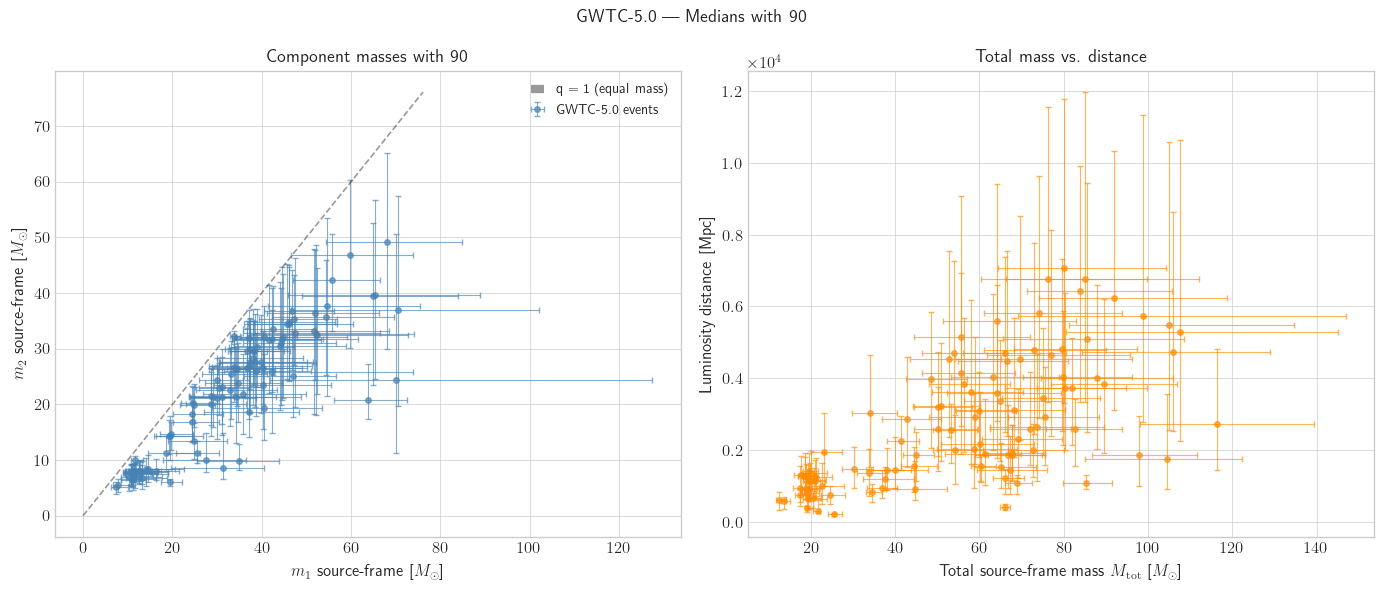

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: component masses m1 vs m2 ─────────────────────────────────────────
x    = np.array(imr_table["mass_1_source_median"])
y    = np.array(imr_table["mass_2_source_median"])
xerr = [np.array(imr_table["mass_1_source_lower"]), np.array(imr_table["mass_1_source_upper"])]
yerr = [np.array(imr_table["mass_2_source_lower"]), np.array(imr_table["mass_2_source_upper"])]

axes[0].errorbar(x, y, xerr=xerr, yerr=yerr,
                 fmt='o', ms=4, alpha=0.65, elinewidth=0.8, capsize=2,
                 color='steelblue', label='GWTC-5.0 events')
m_max = max(x.max(), y.max()) * 1.08
axes[0].plot([0, m_max], [0, m_max], 'k--', alpha=0.4, lw=1.2, label='q = 1 (equal mass)')
axes[0].set_xlabel(r"$m_1$ source-frame [$M_\odot$]")
axes[0].set_ylabel(r"$m_2$ source-frame [$M_\odot$]")
axes[0].set_title("Component masses with 90% CI")
axes[0].legend(fontsize=10)

# ── Right: total mass vs luminosity distance ─────────────────────────────────
x2   = np.array(imr_table["total_mass_source_median"])
y2   = np.array(imr_table["luminosity_distance_median"])
xerr2 = [np.array(imr_table["total_mass_source_lower"]),  np.array(imr_table["total_mass_source_upper"])]
yerr2 = [np.array(imr_table["luminosity_distance_lower"]), np.array(imr_table["luminosity_distance_upper"])]

axes[1].errorbar(x2, y2, xerr=xerr2, yerr=yerr2,
                 fmt='o', ms=4, alpha=0.65, elinewidth=0.8, capsize=2,
                 color='darkorange')
axes[1].set_xlabel(r"Total source-frame mass $M_\mathrm{tot}$ [$M_\odot$]")
axes[1].set_ylabel("Luminosity distance [Mpc]")
axes[1].set_title("Total mass vs. distance")

plt.suptitle("GWTC-5.0  —  Medians with 90% CI error bars  (IMRPhenomXPHM-SpinTaylor)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: chi_eff vs mass ratio, coloured by distance ───────────────────────
q    = np.array(imr_table["mass_ratio_median"])
ce   = np.array(imr_table["chi_eff_median"])
ce_lo = np.array(imr_table["chi_eff_lower"])
ce_hi = np.array(imr_table["chi_eff_upper"])
log_d = np.log10(np.array(imr_table["luminosity_distance_median"]))

sc = axes[0].scatter(q, ce, c=log_d, cmap='plasma', s=40, alpha=0.85, zorder=3)
axes[0].errorbar(q, ce, yerr=[ce_lo, ce_hi],
                 fmt='none', elinewidth=0.7, alpha=0.45, color='gray', zorder=2)
axes[0].axhline(0, color='k', lw=0.9, ls='--', alpha=0.5, label=r'$\chi_\mathrm{eff}=0$')
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label(r'$\log_{10}(d_L/\mathrm{Mpc})$')
axes[0].set_xlabel(r"Mass ratio $q = m_1/m_2$")
axes[0].set_ylabel(r"$\chi_\mathrm{eff}$")
axes[0].set_title(r"Effective spin vs mass ratio (colour = distance)")
axes[0].legend(fontsize=10)

# ── Right: chi_eff population histogram ──────────────────────────────────────
axes[1].hist(ce, bins=20, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='k', lw=1.4, ls='--', label=r'$\chi_\mathrm{eff}=0$')
axes[1].set_xlabel(r"$\chi_\mathrm{eff}$ (median)")
axes[1].set_ylabel("Number of events")
axes[1].set_title(r"Population distribution of $\chi_\mathrm{eff}$")
axes[1].legend()

plt.suptitle(r"GWTC-5.0  —  Spin characteristics",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
### Section 6 · SNR and Measurement Precision

The network SNR $\rho$ is the single most important figure of merit for a GW detection.
In the **high-SNR / Fisher-matrix approximation**, posterior widths scale as:

$$\sigma_\theta \propto \frac{1}{\rho}$$

We can test this empirically. Define the **fractional 90% CI width** for parameter $X$:

$$w_\mathrm{frac}(X) \equiv \frac{X_\mathrm{lower} + X_\mathrm{upper}}{|X_\mathrm{median}|}$$

For a near-Gaussian posterior, $w_\mathrm{frac} \approx 2 \times 1.645\,/\,\rho$, so a
log–log plot of $w_\mathrm{frac}$ vs. SNR should show a slope of approximately $-1$.

> **Exercise:** Does the data follow the $\propto 1/\rho$ expectation? Which parameter is
> best measured relative to others at a given SNR? Is chirp mass better measured than $m_1$?


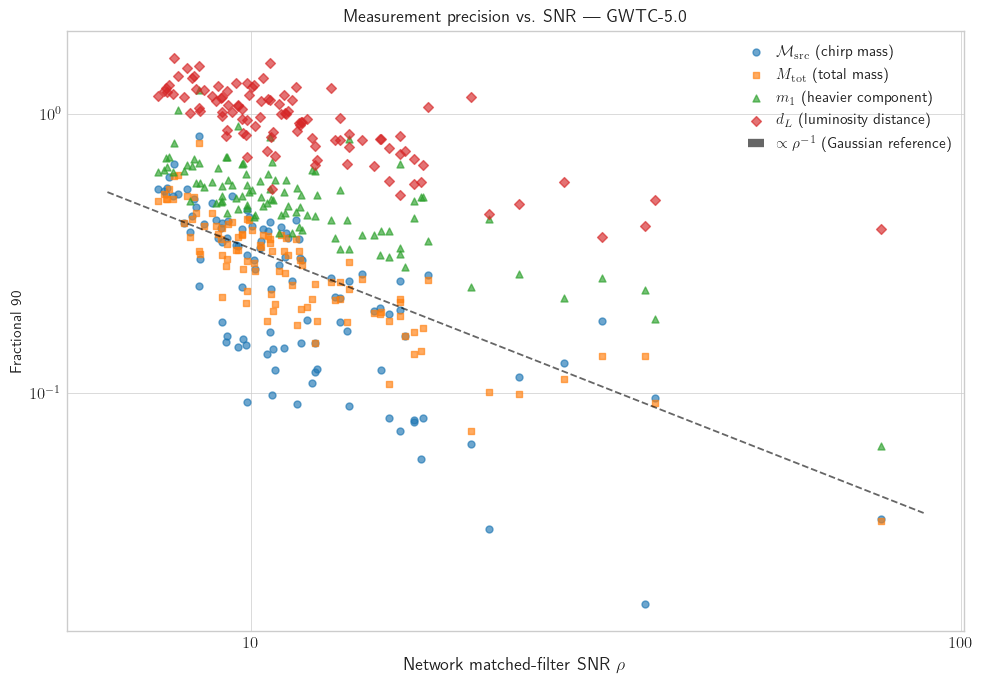


SNR range in this sample: 7.4 – 76.9
Events with valid SNR:    103 / 103


In [7]:
# ── Extract events with valid (unmasked) SNR ──────────────────────────────────
snr_mask = np.array(imr_table["network_matched_filter_snr_median.mask"])
snr_vals = np.array(imr_table["network_matched_filter_snr_median"])
valid    = ~snr_mask
snr      = snr_vals[valid]

# ── Fractional 90% CI widths for key parameters ───────────────────────────────
# (lower + upper) / |median|  — proxy for the inverse of measurement precision
param_info = {
    r"$\mathcal{M}_\mathrm{src}$ (chirp mass)": ("chirp_mass_source_median", "chirp_mass_source_lower",  "chirp_mass_source_upper"),
    r"$M_\mathrm{tot}$ (total mass)":           ("total_mass_source_median",  "total_mass_source_lower",  "total_mass_source_upper"),
    r"$m_1$ (heavier component)":               ("mass_1_source_median",      "mass_1_source_lower",       "mass_1_source_upper"),
    r"$d_L$ (luminosity distance)":             ("luminosity_distance_median","luminosity_distance_lower","luminosity_distance_upper"),
}

colors = ['C0', 'C1', 'C2', 'C3']
markers = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(10, 7))

for (label, (mc, lc, uc)), color, marker in zip(param_info.items(), colors, markers):
    med  = np.abs(np.array(imr_table[mc])[valid])
    lo   = np.array(imr_table[lc])[valid]
    hi   = np.array(imr_table[uc])[valid]
    frac = (lo + hi) / (med + 1e-12)
    ax.scatter(snr, frac, s=25, alpha=0.65, color=color, marker=marker, label=label)

# Reference line: w_frac ~ 2 * 1.645 / SNR  (Gaussian approximation)
snr_ref = np.linspace(snr.min() * 0.85, snr.max() * 1.15, 200)
ax.plot(snr_ref, 3.29 / snr_ref, 'k--', lw=1.3, alpha=0.6,
        label=r'$\propto \rho^{-1}$ (Gaussian reference)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"Network matched-filter SNR $\rho$", fontsize=13)
ax.set_ylabel(r"Fractional 90% CI width $(w_\mathrm{lower}+w_\mathrm{upper})\,/\,|\mathrm{median}|$",
              fontsize=11)
ax.set_title("Measurement precision vs. SNR — GWTC-5.0", fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nSNR range in this sample: {snr.min():.1f} – {snr.max():.1f}")
print(f"Events with valid SNR:    {valid.sum()} / {len(imr_table)}")


### Part 1 — Discussion Questions

1. Which event has the largest total source-frame mass? Is it also the most distant?
2. Is the $\propto 1/\rho$ trend clearly visible? Which parameters follow it best?
3. Why is the chirp mass typically better measured than the individual component masses at the same SNR?
4. Is there a visible trend in $\chi_\mathrm{eff}$ with mass ratio? What would you expect physically?
5. Looking at the $m_1$–$m_2$ scatter plot: do you see evidence for a mass gap?

---
## Part 2: GW250114_082203 — Deep Dive into a Single Event

GW250114_082203 is a binary black hole merger detected on January 14, 2025 during O4b.
It is notable for its high network SNR ($\rho \approx 79$), making it one of the
best-measured events in the catalog.

In this part we work with the **full posterior samples** from the PE analysis, giving
access to the complete multi-dimensional probability distribution over ~140 source,
extrinsic, and calibration parameters.


### Section 7 · Loading the GW250114 Posterior Samples

The `GW250114_PEsummary.hdf5` file is a **PESummary-format** HDF5 file. It stores:
- Full posterior samples for each waveform approximant analysed
- Prior samples used in the run
- Metadata (calibration envelopes, settings, ...)

The file contains results from **four approximants**, giving us an opportunity to
assess waveform systematics by comparing posteriors later.


In [8]:
pe_path = "./GW250114_PEsummary.hdf5"
result  = read(pe_path)

print(f"Loaded:  {pe_path}")
print(f"Type:    {type(result).__name__}")
print()
print("Available waveform approximants:")
print("─" * 55)
for label in result.labels:
    n = len(result.samples_dict[label]['mass_1_source'])
    print(f"  {label:<42s}  {n:>6,} samples")
print("─" * 55)


lal.MSUN_SI != Msun
Loaded:  ./GW250114_PEsummary.hdf5
Type:    PESummary

Available waveform approximants:
───────────────────────────────────────────────────────
  C00:IMRPhenomXPHM-SpinTaylor                13,969 samples
  C00:IMRPhenomXPNR                           16,301 samples
  C00:NRSur7dq4                               17,253 samples
  C00:SEOBNRv5PHM                             16,300 samples
───────────────────────────────────────────────────────


In [9]:
# ── Select one approximant as our reference ───────────────────────────────────
LABEL    = "C00:IMRPhenomXPHM-SpinTaylor"   # same as Part 1
posterior = result.samples_dict[LABEL]

print(f"Working with:  {LABEL}")
print(f"Samples:       {len(posterior['mass_1_source']):,}")
print()

# Group parameters into physics categories
phys_params = [
    "mass_1_source", "mass_2_source", "chirp_mass_source",
    "mass_ratio", "chi_eff", "chi_p",
    "luminosity_distance", "redshift", "theta_jn",
]
snr_params = [
    "H1_matched_filter_snr_abs", "L1_matched_filter_snr_abs",
    "network_matched_filter_snr",
]

print("Physics parameters available:")
for p in phys_params:
    ok = "✓" if p in posterior else "✗"
    print(f"  {ok}  {p}")
print()
print("SNR-related parameters available:")
for p in snr_params:
    ok = "✓" if p in posterior else "✗"
    print(f"  {ok}  {p}")


Working with:  C00:IMRPhenomXPHM-SpinTaylor
Samples:       13,969

Physics parameters available:
  ✓  mass_1_source
  ✓  mass_2_source
  ✓  chirp_mass_source
  ✓  mass_ratio
  ✓  chi_eff
  ✓  chi_p
  ✓  luminosity_distance
  ✓  redshift
  ✓  theta_jn

SNR-related parameters available:
  ✓  H1_matched_filter_snr_abs
  ✓  L1_matched_filter_snr_abs
  ✓  network_matched_filter_snr


---
### Section 8 · One-Dimensional Posterior Histograms

The simplest way to summarise a posterior is through its **marginal 1-D distribution**
for each parameter. For each, we also plot the **90% credible interval** (the region
containing 90% of the posterior probability).

The width of the posterior reflects the measurement precision: a narrow distribution
means the data strongly constrains that parameter; a broad distribution means the data
is not very informative.


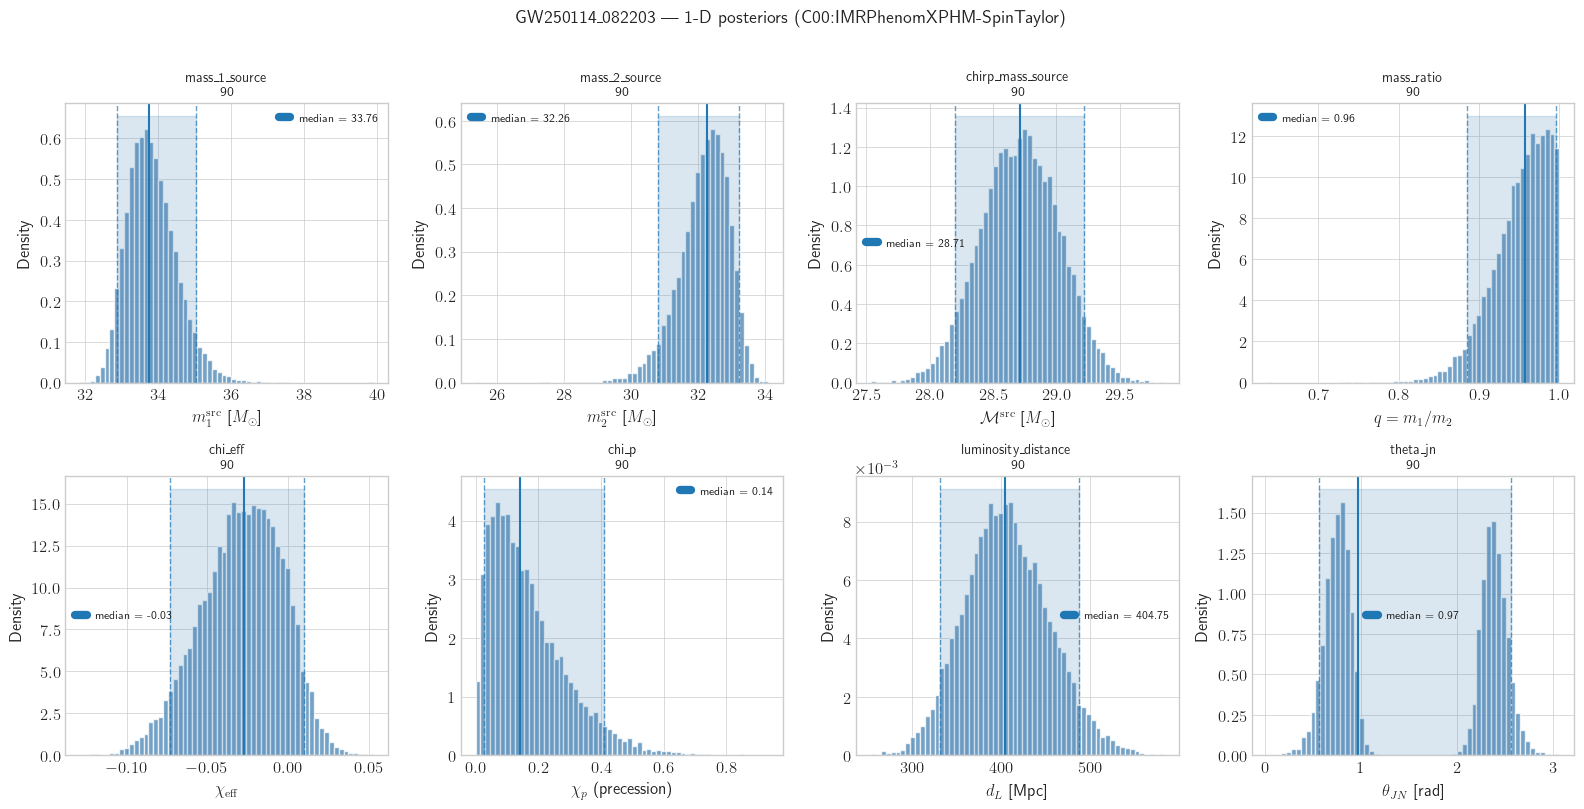

In [10]:
plot_params = [
    ("mass_1_source",       r"$m_1^\mathrm{src}$ [$M_\odot$]"),
    ("mass_2_source",       r"$m_2^\mathrm{src}$ [$M_\odot$]"),
    ("chirp_mass_source",   r"$\mathcal{M}^\mathrm{src}$ [$M_\odot$]"),
    ("mass_ratio",          r"$q = m_1/m_2$"),
    ("chi_eff",             r"$\chi_\mathrm{eff}$"),
    ("chi_p",               r"$\chi_p$ (precession)"),
    ("luminosity_distance", r"$d_L$ [Mpc]"),
    ("theta_jn",            r"$\theta_{JN}$ [rad]"),
]

available = [(p, lbl) for p, lbl in plot_params if p in posterior]
ncols = 4
nrows = int(np.ceil(len(available) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, (param, label) in zip(axes, available):
    samples = np.asarray(posterior[param])
    lo5,  med,  hi95 = np.quantile(samples, [0.05, 0.5, 0.95])

    ax.hist(samples, bins=60, density=True, color='steelblue', alpha=0.75, edgecolor='white')

    # Shade the 90% credible interval
    xs = np.sort(samples)
    mask = (xs >= lo5) & (xs <= hi95)
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                     lo5, hi95, alpha=0.2, color='steelblue')
    ax.axvline(med,  color='C0', lw=1.5, ls='-',  label=f'median = {med:.2f}')
    ax.axvline(lo5,  color='C0', lw=1.0, ls='--', alpha=0.7)
    ax.axvline(hi95, color='C0', lw=1.0, ls='--', alpha=0.7)

    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.set_title(f"{param}\n90% CI: [{lo5:.2f}, {hi95:.2f}]", fontsize=10)
    ax.legend(fontsize=8)

for ax in axes[len(available):]:
    ax.axis("off")

plt.suptitle(f"GW250114_082203  —  1-D posteriors  ({LABEL})",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [14]:
# ── Credible interval summary table ──────────────────────────────────────────
print(f"{'Parameter':<25s}  {'5%':>10}  {'Median':>10}  {'95%':>10}  {'90% width':>10}  {'frac. width':>12}")
print("─" * 82)

summary_rows = []
for param, label in available:
    s = np.asarray(posterior[param])
    lo5, med, hi95 = np.quantile(s, [0.05, 0.5, 0.95])
    width = hi95 - lo5
    frac  = width / abs(med) if med != 0 else float('nan')
    summary_rows.append((param, lo5, med, hi95, width, frac))

# Sort by fractional width (tightest first)
summary_rows.sort(key=lambda r: r[-1])

for param, lo5, med, hi95, width, frac in summary_rows:
    print(f"  {param:<23s}  {lo5:>10.3f}  {med:>10.3f}  {hi95:>10.3f}  {width:>10.3f}  {frac:>12.3f}")


Parameter                          5%      Median         95%   90% width   frac. width
──────────────────────────────────────────────────────────────────────────────────
  chirp_mass_source            28.201      28.715      29.217       1.016         0.035
  mass_1_source                32.866      33.763      35.044       2.178         0.065
  mass_2_source                30.797      32.263      33.212       2.415         0.075
  mass_ratio                    0.885       0.958       0.996       0.110         0.115
  luminosity_distance         331.918     404.748     488.336     156.418         0.386
  theta_jn                      0.566       0.969       2.565       1.999         2.063
  chi_p                         0.026       0.140       0.410       0.384         2.740
  chi_eff                      -0.073      -0.027       0.010       0.083         3.054


---
### Section 9 · Parameter Correlations — Corner Plots

A **corner plot** shows all pairwise 2-D marginal posteriors (as contour plots)
alongside the 1-D marginals on the diagonal. It is the standard visualisation for
multi-dimensional Bayesian posteriors in GW astronomy.

Key correlations to look for:
- $m_1$–$m_2$: anti-correlated along the chirp-mass direction (the chirp mass is
  much better determined than the individual masses)
- $m_1$–$\mathcal{M}$: tight correlation, confirming the chirp mass drives the measurement
- $\chi_\mathrm{eff}$–$q$: possible correlation due to spin-orbit degeneracy

The contours show the **50% and 90% credible regions**.


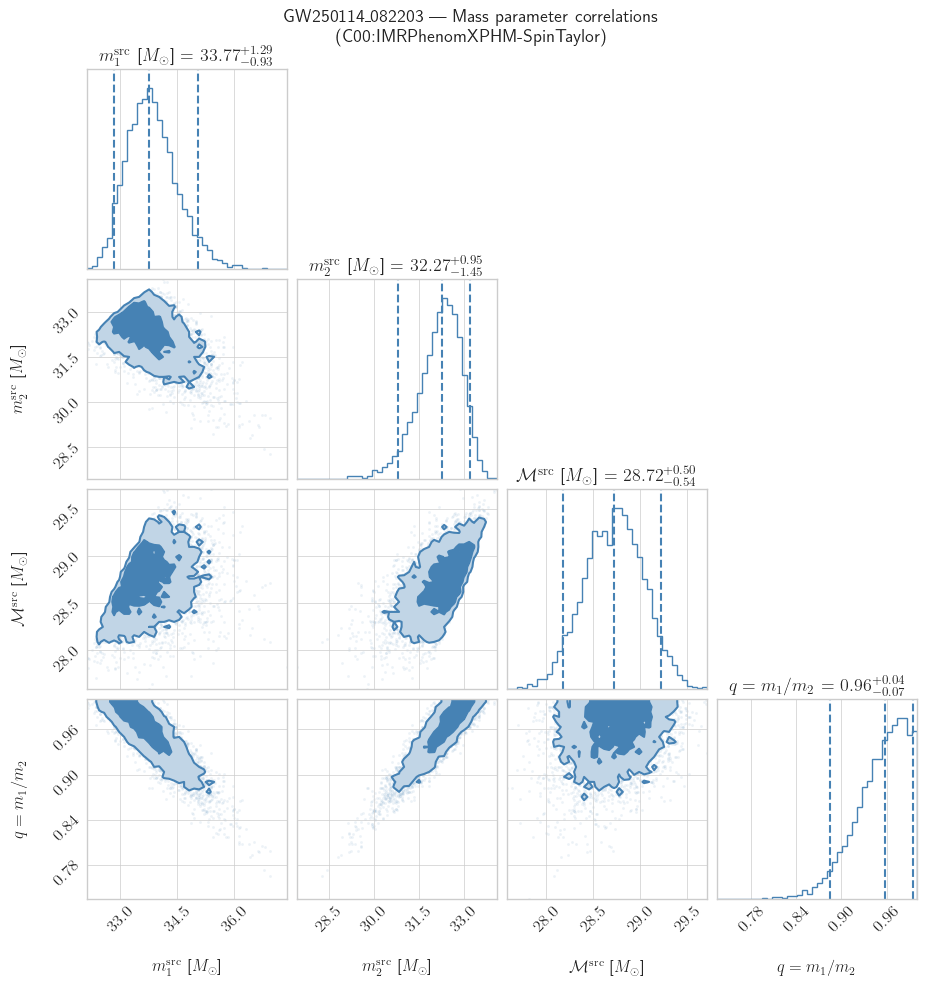

In [11]:
# ── Corner plot: mass parameters ─────────────────────────────────────────────
mass_corner_params = ['mass_1_source', 'mass_2_source', 'chirp_mass_source', 'mass_ratio']
mass_labels = [
    r'$m_1^\mathrm{src}$ [$M_\odot$]',
    r'$m_2^\mathrm{src}$ [$M_\odot$]',
    r'$\mathcal{M}^\mathrm{src}$ [$M_\odot$]',
    r'$q = m_1/m_2$',
]

avail = [p for p in mass_corner_params if p in posterior]
data_mass = np.column_stack([np.asarray(posterior[p]) for p in avail])
labels_mass = [mass_labels[mass_corner_params.index(p)] for p in avail]

# Thin the samples for speed (corner works on ~5000 samples)
idx_thin = np.random.default_rng(42).choice(len(data_mass), size=min(5000, len(data_mass)), replace=False)

fig_mass = corner.corner(
    data_mass[idx_thin],
    labels=labels_mass,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt='.2f',
    levels=[0.5, 0.9],
    fill_contours=True,
    bins=40,
    color='steelblue',
)
fig_mass.suptitle(f'GW250114_082203 — Mass parameter correlations\n({LABEL})',
                  fontsize=13, fontweight='bold', y=1.02)
plt.show()


In [ ]:
# ── Corner plot: spin + extrinsic parameters ─────────────────────────────────
extr_corner_params = ['chi_eff', 'chi_p', 'mass_ratio', 'theta_jn', 'luminosity_distance']
extr_labels = [
    r'$\chi_\mathrm{eff}$',
    r'$\chi_p$',
    r'$q$',
    r'$\theta_{JN}$ [rad]',
    r'$d_L$ [Mpc]',
]

avail_extr = [p for p in extr_corner_params if p in posterior]
data_extr  = np.column_stack([np.asarray(posterior[p]) for p in avail_extr])
labels_extr = [extr_labels[extr_corner_params.index(p)] for p in avail_extr]

fig_extr = corner.corner(
    data_extr[idx_thin],
    labels=labels_extr,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt='.2f',
    levels=[0.5, 0.9],
    fill_contours=True,
    bins=40,
    color='darkorange',
)
fig_extr.suptitle(f'GW250114_082203 — Spin and extrinsic parameter correlations\n({LABEL})',
                  fontsize=13, fontweight='bold', y=1.02)
plt.show()


---
### Section 10 · Prior vs. Posterior Comparison

Comparing the **prior** (what we assumed before looking at the data) to the
**posterior** (what we inferred after) directly reveals the **information gain**
from the gravitational-wave observation.

A posterior that is very different from the prior means the data strongly constrains
that parameter. A posterior that closely resembles the prior means the data has little
to say about it.

We use **prior samples** stored inside the same HDF5 file.


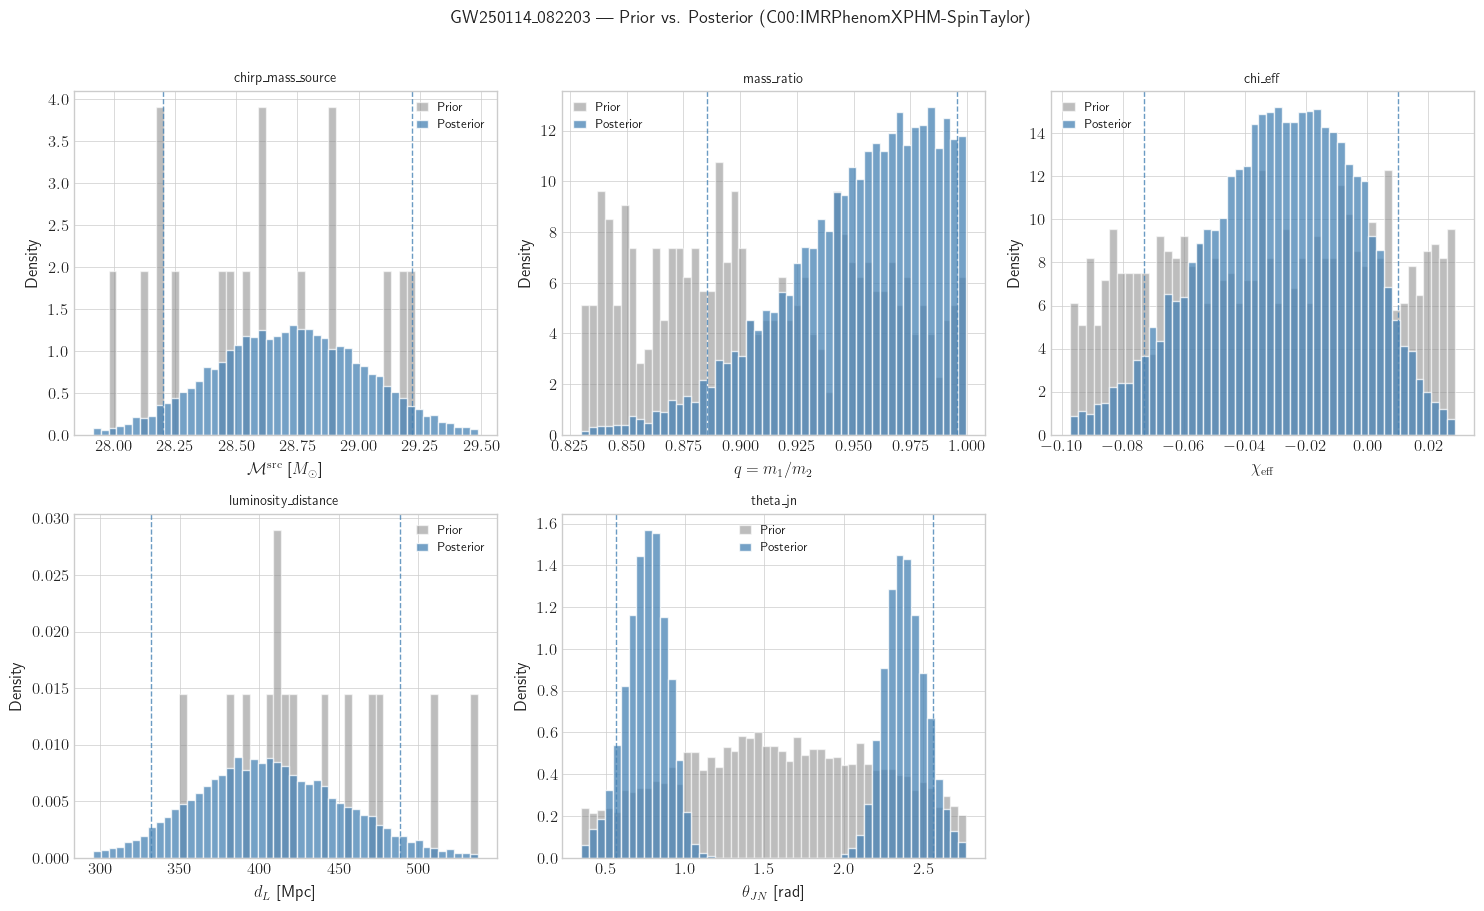

In [19]:
# ── Load prior samples ────────────────────────────────────────────────────────
prior_samples = result.priors['samples'][LABEL]

compare_params = [
    ("chirp_mass_source",       r"$\mathcal{M}^\mathrm{src}$ [$M_\odot$]"),
    ("mass_ratio",          r"$q = m_1/m_2$"),
    ("chi_eff",             r"$\chi_\mathrm{eff}$"),
    ("luminosity_distance", r"$d_L$ [Mpc]"),
    ("theta_jn",            r"$\theta_{JN}$ [rad]"),
]
available_cp = [(p, lbl) for p, lbl in compare_params
                if p in posterior and p in prior_samples]

ncols = 3
nrows = int(np.ceil(len(available_cp) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, (param, label) in zip(axes, available_cp):
    post = np.asarray(posterior[param])
    pri  = np.asarray(prior_samples[param])

    # Common range: use 0.5th–99.5th percentile of the posterior (prior can be wide)
    lo = np.nanpercentile(post, 0.5)
    hi = np.nanpercentile(post, 99.5)
    bins = np.linspace(lo, hi, 50)

    ax.hist(pri,  bins=bins, density=True, alpha=0.55, color='#888888', label='Prior',     edgecolor='white')
    ax.hist(post, bins=bins, density=True, alpha=0.75, color='steelblue', label='Posterior', edgecolor='white')

    # 90% CI lines for posterior
    lo5, hi95 = np.quantile(post, [0.05, 0.95])
    ax.axvline(lo5,  color='steelblue', lw=1.0, ls='--', alpha=0.8)
    ax.axvline(hi95, color='steelblue', lw=1.0, ls='--', alpha=0.8)

    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.set_title(param, fontsize=10)
    ax.legend(fontsize=9)

for ax in axes[len(available_cp):]:
    ax.axis("off")

plt.suptitle(f"GW250114_082203  —  Prior vs. Posterior  ({LABEL})",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
### Section 11 · Waveform Model Comparison

Different waveform approximants describe the same physical system with different
approximations. Comparing the posteriors across models tells us:

1. Whether the **measurement is robust** (models agree → systematics are small)
2. Which parameters are most **sensitive to waveform modelling** (models disagree)

For GW250114, four models are available. We overlay their posteriors for the key
intrinsic parameters. Broad agreement indicates the result is reliable; significant
offsets would flag potential systematic uncertainty.


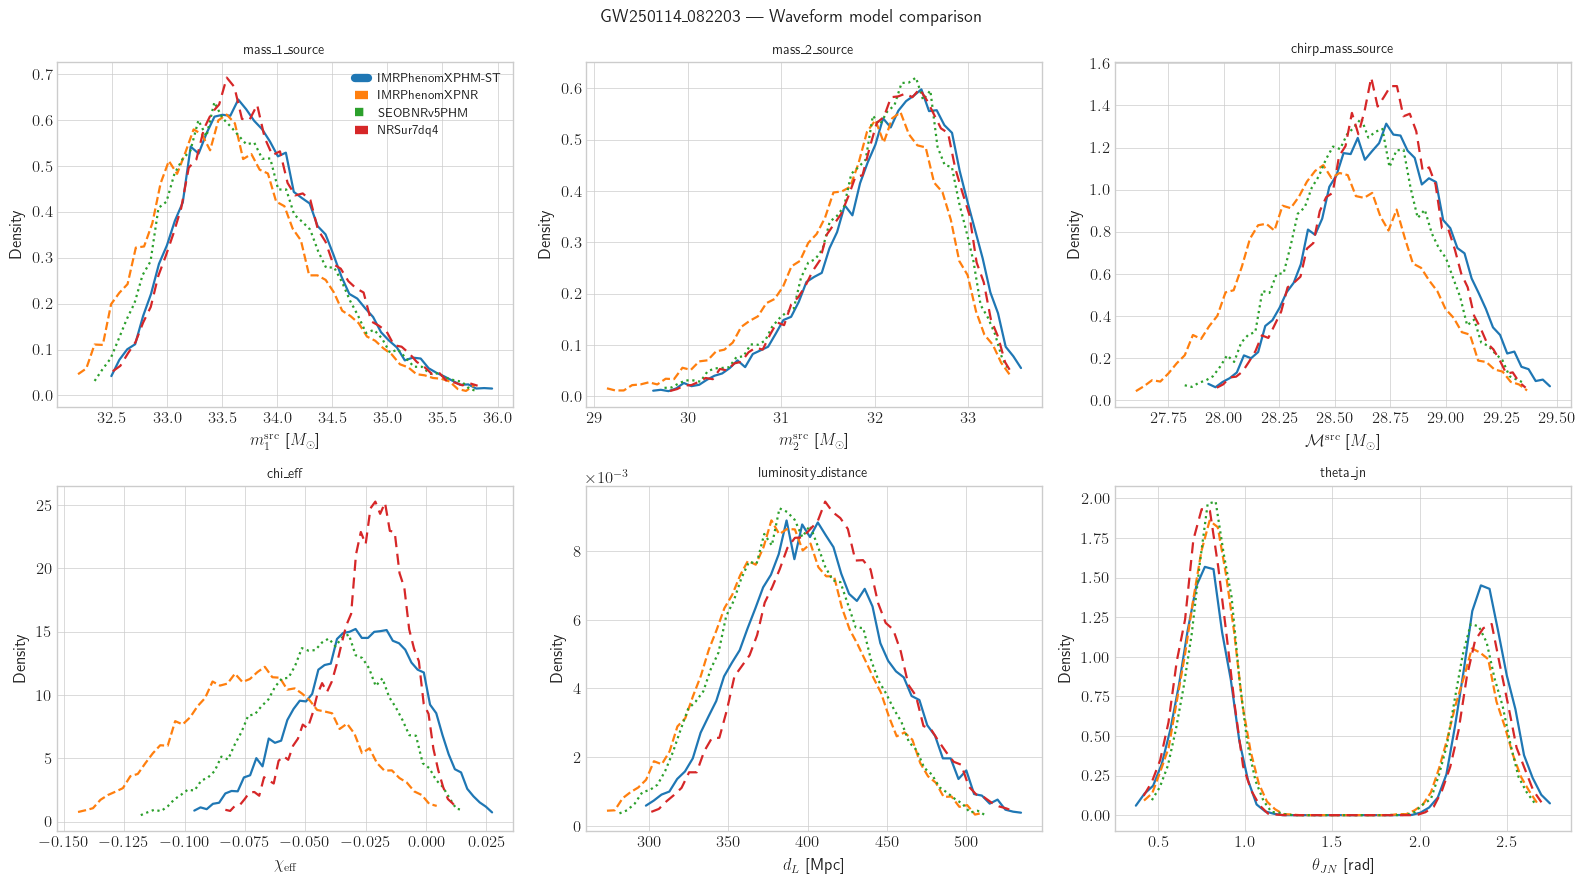

In [13]:
compare_wf_params = [
    ("mass_1_source",       r"$m_1^\mathrm{src}$ [$M_\odot$]"),
    ("mass_2_source",       r"$m_2^\mathrm{src}$ [$M_\odot$]"),
    ("chirp_mass_source",   r"$\mathcal{M}^\mathrm{src}$ [$M_\odot$]"),
    ("chi_eff",             r"$\chi_\mathrm{eff}$"),
    ("luminosity_distance", r"$d_L$ [Mpc]"),
    ("theta_jn",            r"$\theta_{JN}$ [rad]"),
]

model_styles = {
    "C00:IMRPhenomXPHM-SpinTaylor": ("C0",       "solid",  "IMRPhenomXPHM-ST"),
    "C00:IMRPhenomXPNR":            ("C1",       "dashed", "IMRPhenomXPNR"),
    "C00:SEOBNRv5PHM":              ("C2",       "dotted", "SEOBNRv5PHM"),
    "C00:NRSur7dq4":                ("C3",       (0,(5,3)),"NRSur7dq4"),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (param, label) in zip(axes, compare_wf_params):
    for model_lbl, (color, ls, short) in model_styles.items():
        if model_lbl not in result.labels:
            continue
        samp = result.samples_dict[model_lbl]
        if param not in samp:
            continue
        s = np.asarray(samp[param])
        lo = np.nanpercentile(s, 0.5)
        hi = np.nanpercentile(s, 99.5)
        bins = np.linspace(lo, hi, 50)
        counts, edges = np.histogram(s, bins=bins, density=True)
        centres = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centres, counts, color=color, ls=ls, lw=1.6, label=short)

    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.set_title(param, fontsize=10)

# Shared legend in top-left panel
axes[0].legend(fontsize=9, loc='upper right')

plt.suptitle("GW250114_082203  —  Waveform model comparison",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Summary

| Section | What we did | Key takeaway |
|---------|-------------|--------------|
| **1** | Loaded the GWTC-5.0 PESummary Table | 104 events, 9 approximant runs, 45 columns |
| **2** | Explored the dataset structure | Lower/upper columns are CI **offsets**, not absolute values |
| **3** | Selected one consistent waveform model | `IMRPhenomXPHM-SpinTaylor` covers 103/104 events |
| **4** | Computed derived quantities | Mass ratio $q$, symmetric mass ratio $\eta$ |
| **5** | Population scatter plots with error bars | $m_1$–$m_2$ plane; distance–mass trends visible |
| **6** | SNR vs. measurement precision | Fractional width $\propto 1/\rho$ as expected; chirp mass is best measured |
| **7** | Loaded GW250114 posterior file | 4 approximants, ~5 000 samples each, 141 parameters |
| **8** | 1-D posterior histograms | Chirp mass best constrained; $\theta_{JN}$ and $\chi_p$ broad |
| **9** | Corner plots | Clear $m_1$–$m_2$ anti-correlation along constant $\mathcal{M}$; $\chi_\mathrm{eff}$–$q$ mild correlation |
| **10** | Prior vs. posterior | Strong data update for masses and $\chi_\mathrm{eff}$; distance less constrained |
| **11** | Waveform model comparison | Good agreement across approximants, especially for $\mathcal{M}$ and $\chi_\mathrm{eff}$ |